# ❤️ Heart Disease Prediction Pipeline

## 1. Data Loading
## 2. Exploratory Data Analysis
## 3. Data Preprocessing
## 4. ML Pipeline
## 5. Model Training
## 6. Model Evaluation
## 7. Explainable AI (SHAP)
## 8. Local Explanation (LIME)
## 9. Model Saving

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn import preprocessing
from sklearn.metrics import recall_score, accuracy_score, confusion_matrix, f1_score, matthews_corrcoef
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import precision_score, auc, roc_auc_score, roc_curve, precision_recall_curve, classification_report, make_scorer
import pickle
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
warnings.filterwarnings('ignore')

## 1. Data Loading


In [17]:
#displaying last 5 patient data
df = pd.read_csv('/content/heart_cleveland_upload.csv')

df.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


##EDA

In [18]:
df.shape
df.info()
df.describe(include='all')
df.corr()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        297 non-null    int64  
 1   sex        297 non-null    int64  
 2   cp         297 non-null    int64  
 3   trestbps   297 non-null    int64  
 4   chol       297 non-null    int64  
 5   fbs        297 non-null    int64  
 6   restecg    297 non-null    int64  
 7   thalach    297 non-null    int64  
 8   exang      297 non-null    int64  
 9   oldpeak    297 non-null    float64
 10  slope      297 non-null    int64  
 11  ca         297 non-null    int64  
 12  thal       297 non-null    int64  
 13  condition  297 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 32.6 KB


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
age,1.000000,-0.092399,0.110471,0.290476,0.202644,0.132062,0.149917,-0.394563,0.096489,0.197123,0.159405,0.362210,0.120795,0.227075
sex,-0.092399,1.000000,0.008908,-0.066340,-0.198089,0.038850,0.033897,-0.060496,0.143581,0.106567,0.033345,0.091925,0.370556,0.278467
cp,0.110471,0.008908,1.000000,-0.036980,0.072088,-0.057663,0.063905,-0.339308,0.377525,0.203244,0.151079,0.235644,0.266275,0.408945
trestbps,0.290476,-0.066340,-0.036980,1.000000,0.131536,0.180860,0.149242,-0.049108,0.066691,0.191243,0.121172,0.097954,0.130612,0.153490
chol,0.202644,-0.198089,0.072088,0.131536,1.000000,0.012708,0.165046,-0.000075,0.059339,0.038596,-0.009215,0.115945,0.023441,0.080285
fbs,0.132062,0.038850,-0.057663,0.180860,0.012708,1.000000,0.068831,-0.007842,-0.000893,0.008311,0.047819,0.152086,0.051038,0.003167
restecg,0.149917,0.033897,0.063905,0.149242,0.165046,0.068831,1.000000,-0.072290,0.081874,0.113726,0.135141,0.129021,0.013612,0.166343
thalach,-0.394563,-0.060496,-0.339308,-0.049108,-0.000075,-0.007842,-0.072290,1.000000,-0.384368,-0.347640,-0.389307,-0.268727,-0.258386,-0.423817
exang,0.096489,0.143581,0.377525,0.066691,0.059339,-0.000893,0.081874,-0.384368,1.000000,0.289310,0.250572,0.148232,0.323268,0.421355
oldpeak,0.197123,0.106567,0.203244,0.191243,0.038596,0.008311,0.113726,-0.347640,0.289310,1.000000,0.579037,0.294452,0.336809,0.424052


Total HF = 137
Total NO HF = 160


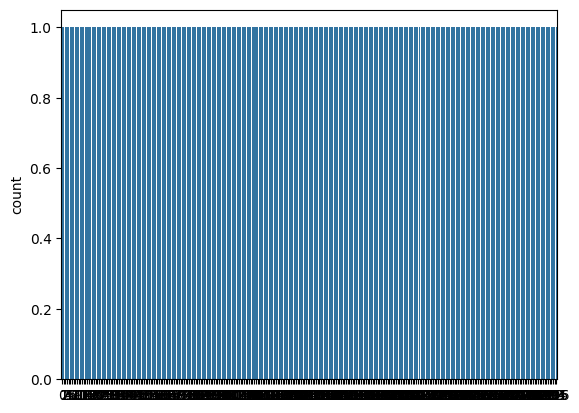

In [19]:

HF = df[df["condition"] == 1].shape[0]
Not_HF = df[df["condition"] == 0].shape[0]

print(f"Total HF = {HF}")
print(f"Total NO HF = {Not_HF}")

sns.countplot(df['condition'])
plt.show()

In [20]:
df.isna().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


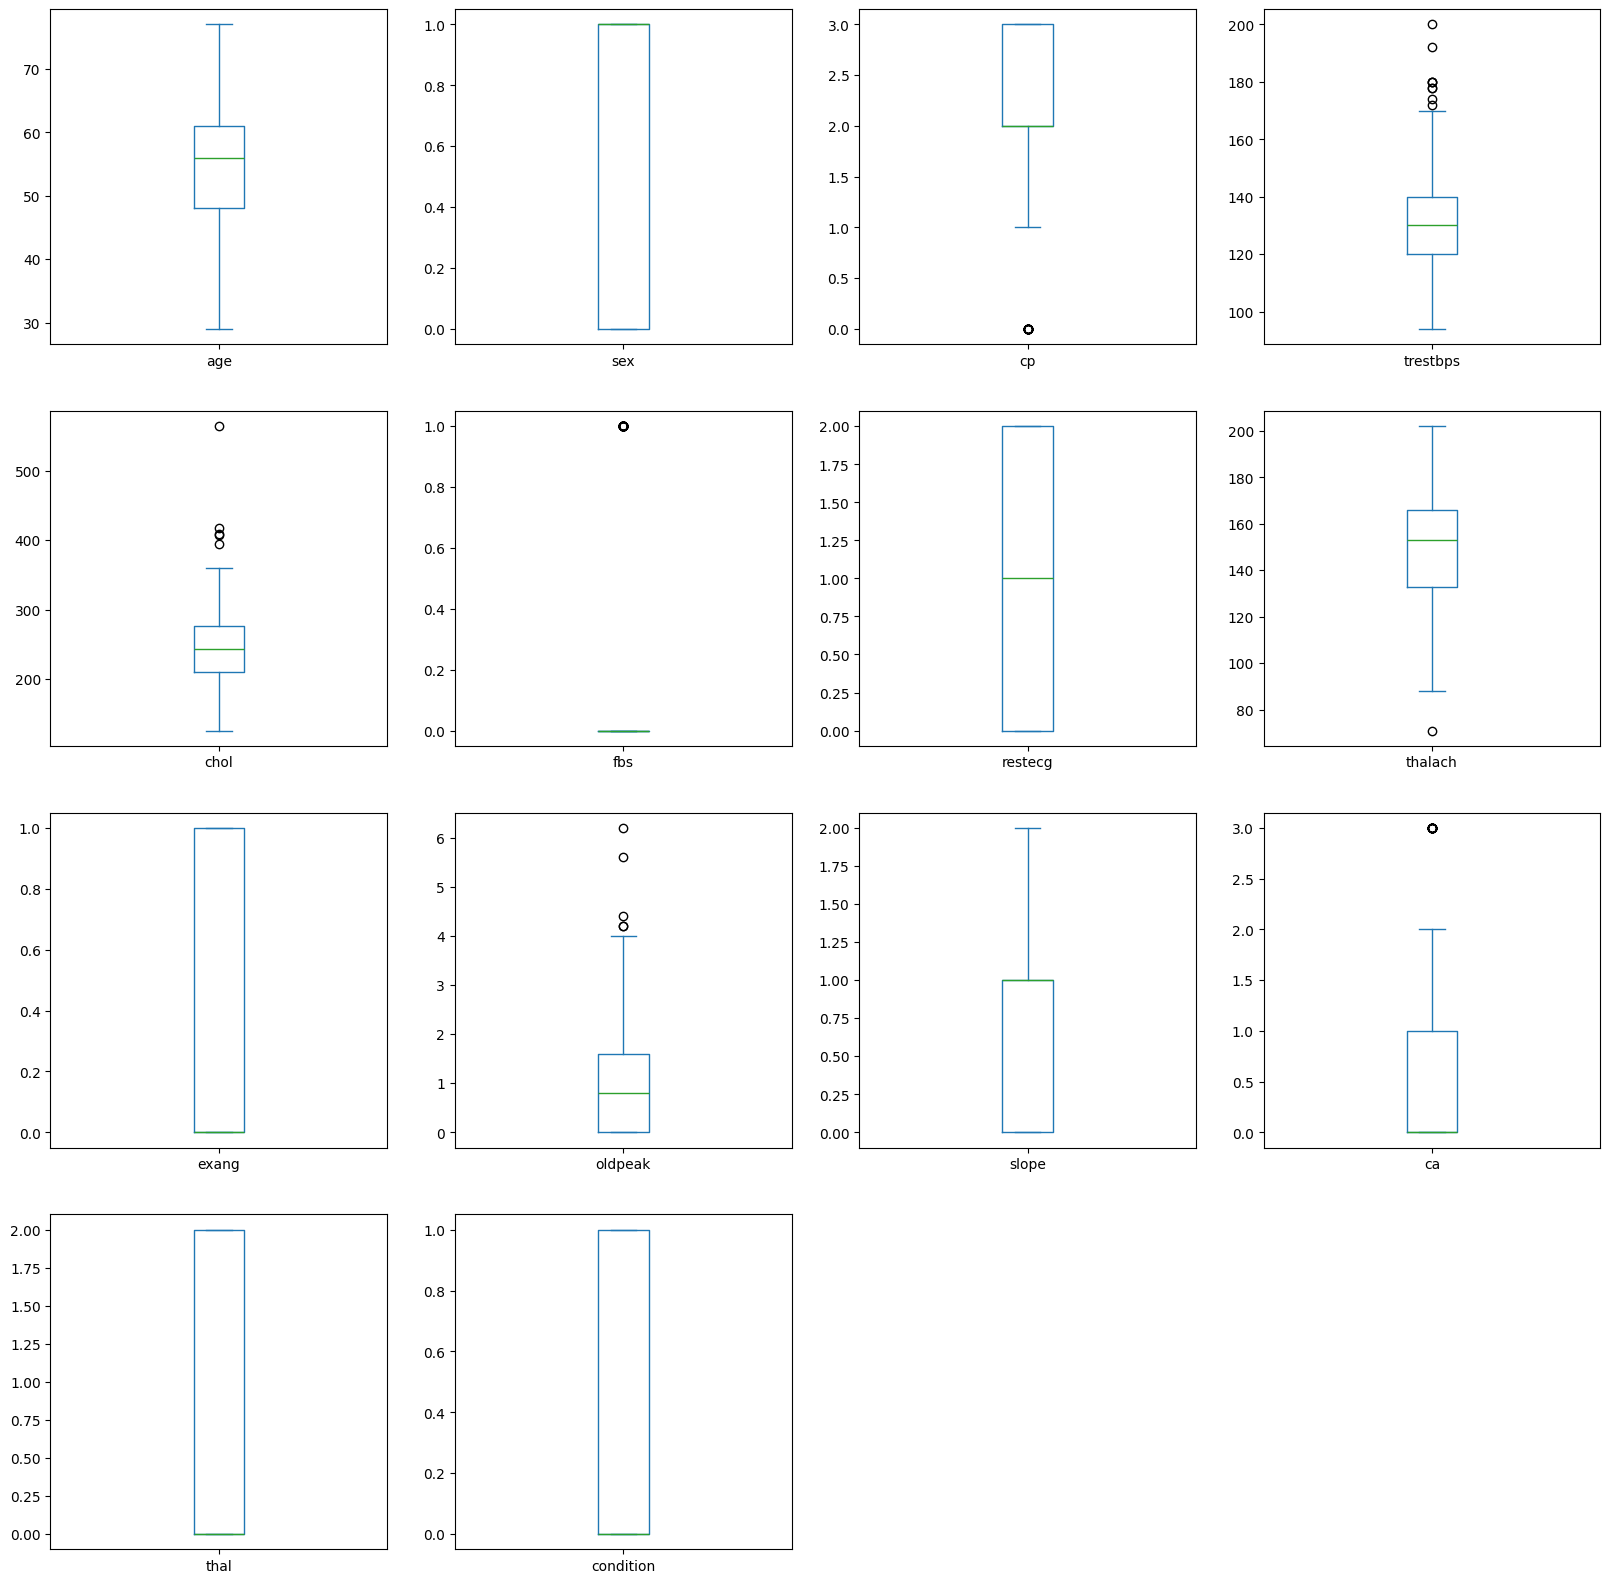

In [21]:
#original data plot using BOX
fig = plt.figure(figsize=(20, 20))
ax = fig.gca()
df.plot(kind='box', subplots=True, layout=(4, 4), sharex=False, ax=ax)
plt.show()

In [24]:
cols = ['trestbps','oldpeak','chol'] # one or more columns with outlier

Q1 = df[cols].quantile(0.25)
Q3 = df[cols].quantile(0.75)
IQR = Q3 - Q1
print('total outlier : \n',((df[cols] < (Q1 - 1.5 * IQR)) | (df[cols] > (Q3 + 1.5 * IQR))).sum())
df = df[~((df[cols] < (Q1 - 1.5 * IQR)) |(df[cols] > (Q3 + 1.5 * IQR))).any(axis=1)]

total outlier : 
 trestbps    9
oldpeak     5
chol        5
dtype: int64


In [23]:
df.shape

(297, 14)

In [26]:
upper_limit = Q1 + 1.5 * IQR
lower_limit = Q3 - 1.5 * IQR

In [27]:
new_df = df[cols] < upper_limit
new_df.shape

(279, 3)

In [28]:
df[cols] = np.where(df[cols] >= upper_limit,
        upper_limit,
        np.where(df[cols] <= lower_limit,
        lower_limit,
        df[cols]))

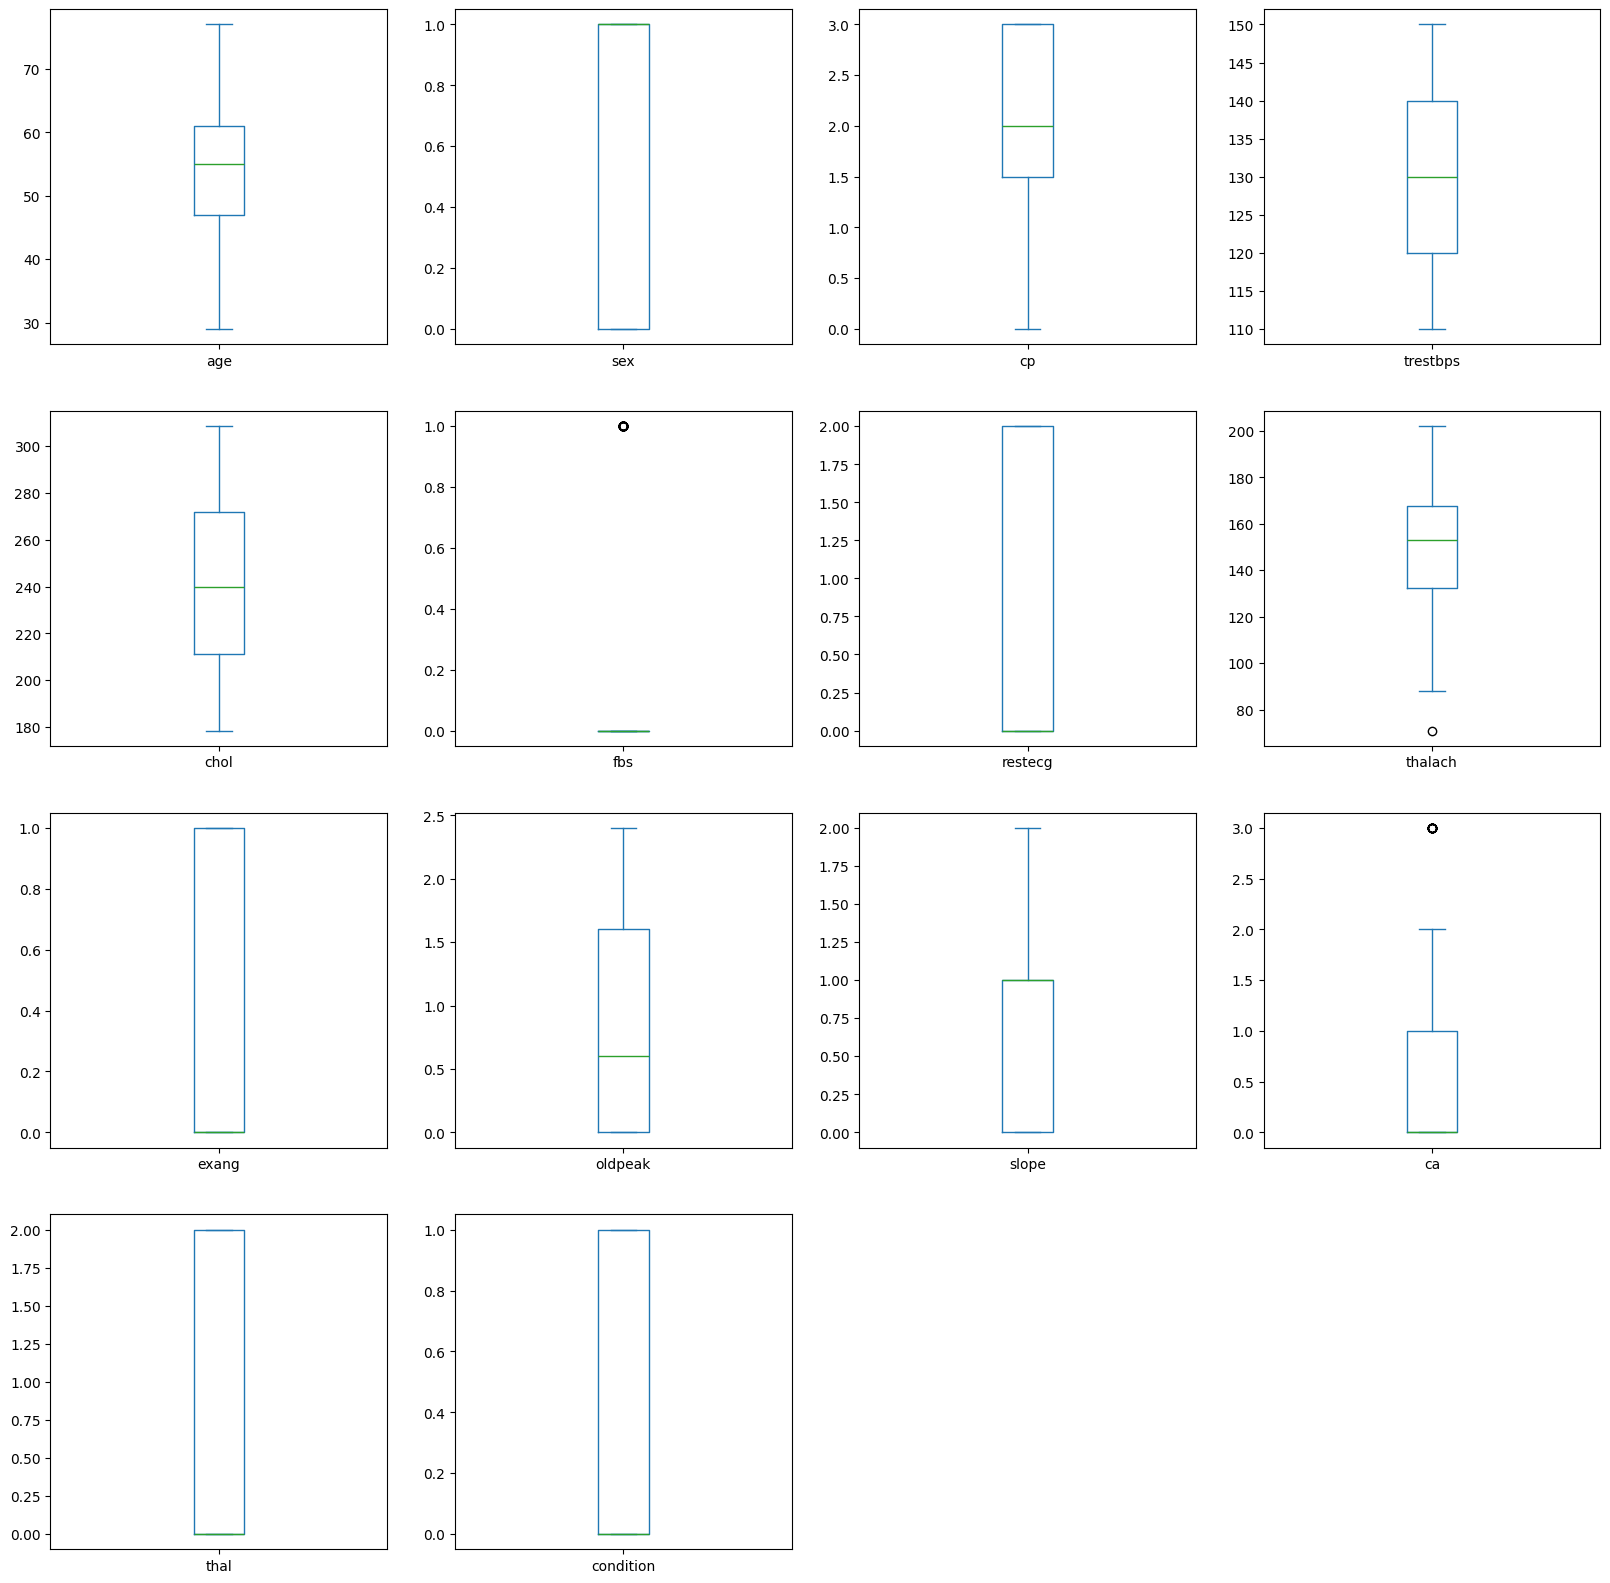

In [29]:
fig = plt.figure(figsize=(20, 20))
ax = fig.gca()
df.plot(kind='box', subplots=True, layout=(4, 4), sharex=False, ax=ax)
plt.show()

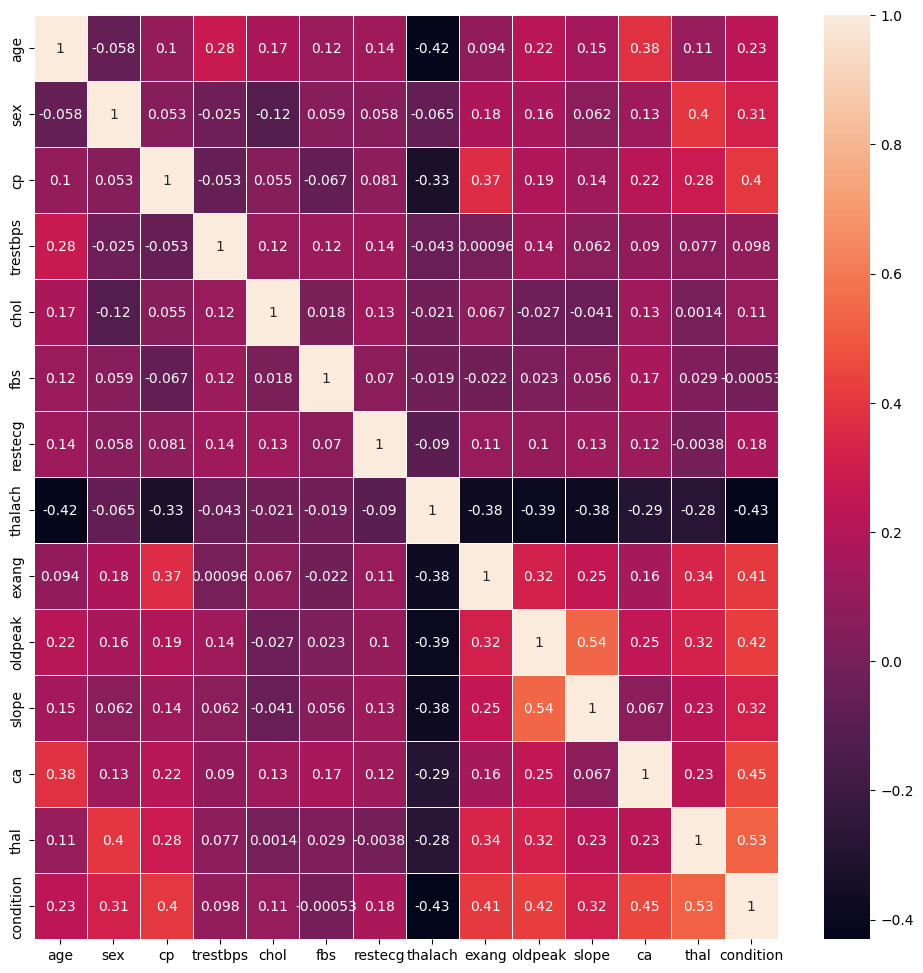

In [30]:
#displaying correlation matrix
fig, ax = plt.subplots(figsize = (12,12))
sns.heatmap(df.corr(), annot = True, linewidths = .5, ax = ax)
plt.show()

In [31]:
categorical_val = []
continous_val = []
for column in df.columns:
    if len(df[column].unique()) <= 10:
        categorical_val.append(column)
    else:
        continous_val.append(column)

In [32]:
categorical_val

['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'condition']

In [33]:
unique_vals=[]

for col in df.columns:
    unival=df[col].nunique()
    unique_vals.append(unival)

#Presenting the findings using a dataframe
pd.DataFrame(unique_vals,columns=['Unique_Values'],index=df.columns)

,Unique_Values
age,41
sex,2
cp,4
trestbps,26
chol,112
fbs,2
restecg,3
thalach,89
exang,2
oldpeak,25


In [34]:
# --- Creating Dummy Variables for cp, thal and slope ---
cp = pd.get_dummies(df['cp'], prefix='cp')
ecg = pd.get_dummies(df['restecg'], prefix='restecg')
slope = pd.get_dummies(df['slope'], prefix='slope')
ca =  pd.get_dummies(df['ca'], prefix='ca')
thal =  pd.get_dummies(df['thal'], prefix='thal')

# --- Merge Dummy Variables to Main Data Frame ---
frames = [df, cp, ecg, slope,ca,thal]
df = pd.concat(frames, axis = 1)

In [35]:
df = df.drop(columns = ['cp', 'restecg', 'slope','ca','thal'])

In [36]:
df.describe()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,condition
count,279.000000,279.000000,279.000000,279.000000,279.000000,279.000000,279.000000,279.000000,279.000000
mean,54.218638,0.695341,129.526882,242.650538,0.136201,149.716846,0.315412,0.890323,0.448029
std,9.152517,0.461090,13.131809,39.742638,0.343618,23.175017,0.465515,0.880001,0.498185
min,29.000000,0.000000,110.000000,178.500000,0.000000,71.000000,0.000000,0.000000,0.000000
25%,47.000000,0.000000,120.000000,211.000000,0.000000,132.500000,0.000000,0.000000,0.000000
50%,55.000000,1.000000,130.000000,240.000000,0.000000,153.000000,0.000000,0.600000,0.000000
75%,61.000000,1.000000,140.000000,272.000000,0.000000,167.500000,1.000000,1.600000,1.000000
max,77.000000,1.000000,150.000000,308.500000,1.000000,202.000000,1.000000,2.400000,1.000000


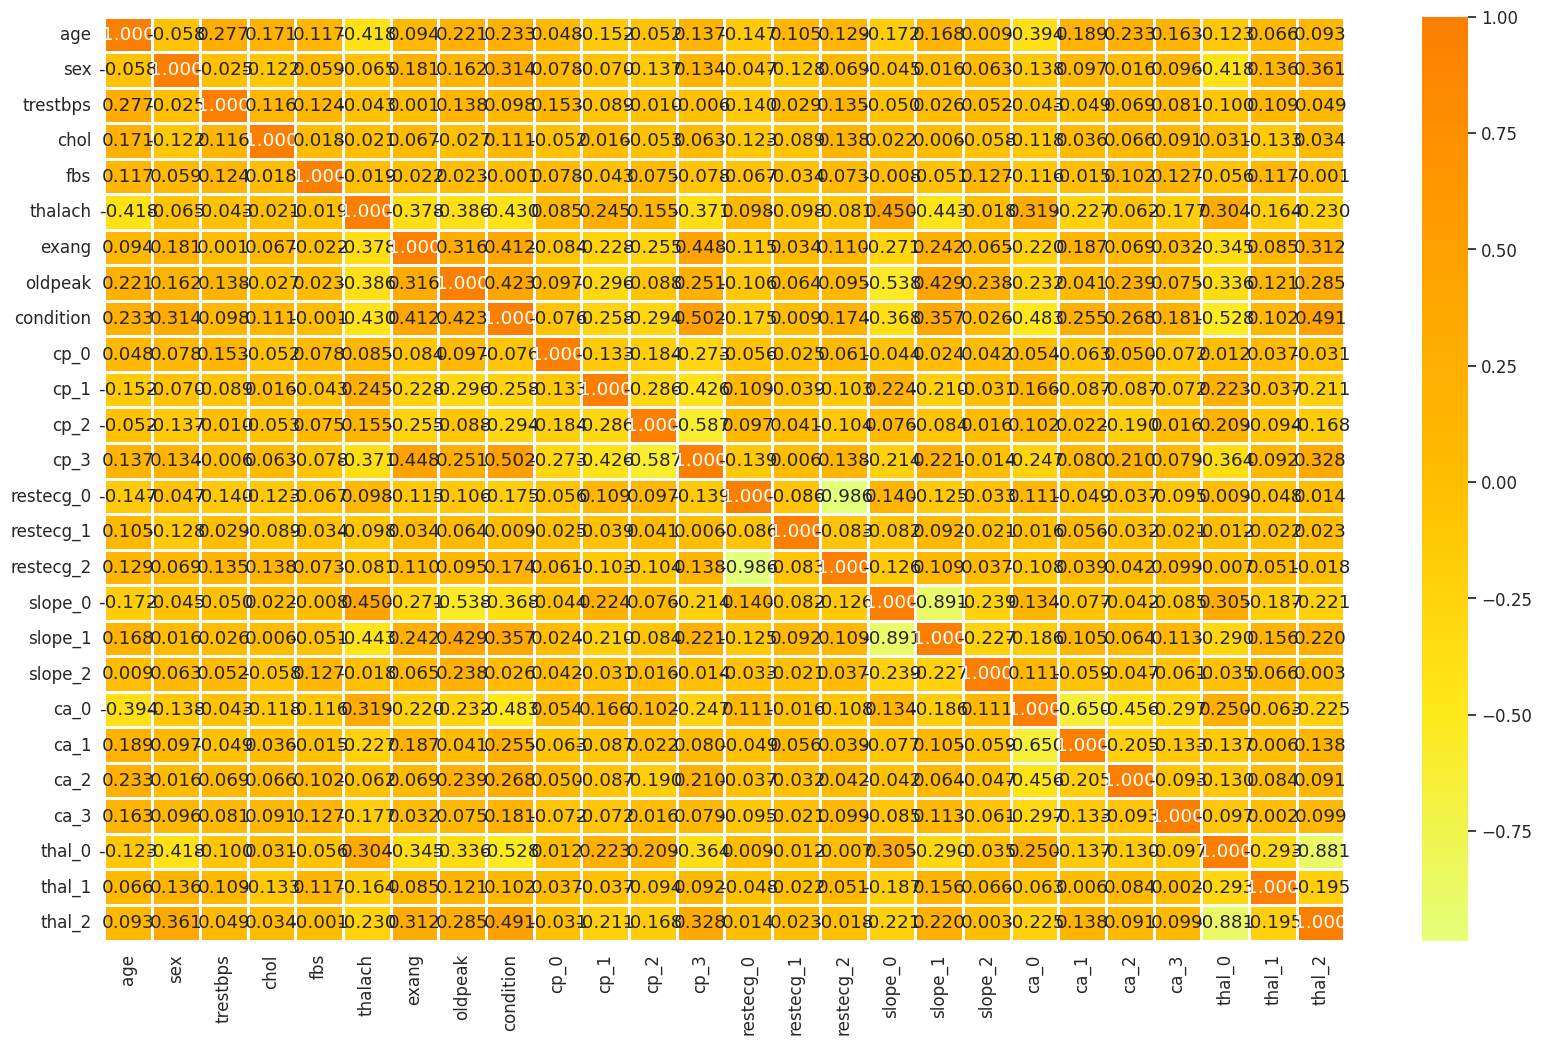

In [37]:
# Correlation heatmap between variables:

sns.set(font_scale=1.1)
correlation_train = df.corr()
mask = np.triu(correlation_train.corr())
plt.figure(figsize=(20, 12))
sns.heatmap(correlation_train,
            annot=True,
            fmt='.3f',
            cmap='Wistia',
            linewidths=1,
            cbar=True)

plt.show()

In [38]:
print(df.corr()["condition"].abs().sort_values(ascending=False))

condition    1.000000
thal_0       0.527529
cp_3         0.502177
thal_2       0.490670
ca_0         0.482744
thalach      0.430456
oldpeak      0.422639
exang        0.412173
slope_0      0.367541
slope_1      0.356577
sex          0.314481
cp_2         0.294268
ca_2         0.268062
cp_1         0.257910
ca_1         0.254680
age          0.233255
ca_3         0.180773
restecg_0    0.175470
restecg_2    0.174016
chol         0.111403
thal_1       0.101949
trestbps     0.098499
cp_0         0.076395
slope_2      0.025777
restecg_1    0.008880
fbs          0.000527
Name: condition, dtype: float64


##Preprocessing

In [39]:
df = df.drop(columns = ['restecg_1', 'fbs', 'slope_2','cp_0','trestbps','thal_1'])

In [40]:
from sklearn.model_selection import train_test_split
from matplotlib import pyplot
X = df.drop("condition",axis=1)
y = df["condition"]

In [41]:


X_train, X_test, y_train, y_test =  train_test_split(X,y,test_size = 0.20, random_state= 42,stratify=df['condition'])

In [42]:
from sklearn.model_selection import RepeatedStratifiedKFold,GridSearchCV,StratifiedKFold

In [43]:
from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()
X_train = sc_X.fit_transform(X_train)
X_test = sc_X.transform(X_test)

##Model training

In [44]:
import xgboost as xgb

#modelXGB = xgb.XGBClassifier(objective="binary:logistic", max_depth =7, min_child_weight=5, random_state=42)
modelXGB = xgb.XGBClassifier(reg_lambda=97.30065,reg_alpha=1.134854,gamma=0.761624,colsample_bytree=0.658399, max_depth =3, min_child_weight=3,n_estimators=801,learning_rate =0.309467,subsample=0.642807)
modelXGB.fit(X_train, y_train)

y_pred = modelXGB.predict(X_test)
print('Accuracy Score:', metrics.accuracy_score(y_test,y_pred))

Accuracy Score: 0.7678571428571429


In [45]:
from hyperopt import STATUS_OK, Trials, fmin, hp, tpe
space={'max_depth': hp.quniform("max_depth", 3, 18, 1),
        'gamma': hp.uniform ('gamma', 1,9),
        'reg_alpha' : hp.quniform('reg_alpha', 40,180,1),
        'reg_lambda' : hp.uniform('reg_lambda', 0,1),
        'colsample_bytree' : hp.uniform('colsample_bytree', 0.5,1),
        'min_child_weight' : hp.quniform('min_child_weight', 0, 10, 1),
        'n_estimators': hp.quniform('n_estimators', 800, 900, 10),
        'seed': 0
    }

In [46]:
def objective(space):
    clf=xgb.XGBClassifier(
                    n_estimators =int (space['n_estimators']), max_depth = int(space['max_depth']), gamma = space['gamma'],
                    reg_alpha = int(space['reg_alpha']),min_child_weight=int(space['min_child_weight']),
                    colsample_bytree=int(space['colsample_bytree']))

    evaluation = [( X_train, y_train), ( X_test, y_test)]

    clf.fit(X_train, y_train,
            eval_set=evaluation, eval_metric="auc",
            early_stopping_rounds=10,verbose=False)


    pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, pred>0.5)
    print ("SCORE:", accuracy)
    return {'loss': -accuracy, 'status': STATUS_OK }

In [48]:
scoring = {'accuracy' : make_scorer(accuracy_score),
           'precision' : make_scorer(precision_score),
           'recall' : make_scorer(recall_score),
           'f1_score' : make_scorer(f1_score)}

stratifyKF=StratifiedKFold(n_splits=10,random_state=42,shuffle=True)
XGB_score= cross_validate(modelXGB, X_train, y_train, cv=stratifyKF,scoring=scoring)
print(XGB_score)

print('accuracy',np.mean(XGB_score['test_accuracy']))
print('precision',np.mean(XGB_score['test_precision']))
print('recall',np.mean(XGB_score['test_recall']))
print('f1 score',np.mean(XGB_score['test_f1_score']))

{'fit_time': array([0.22379303, 0.25069308, 0.183779  , 0.35336137, 0.18913484,
       0.22976089, 0.29361057, 0.3524704 , 0.31147432, 0.22158885]), 'score_time': array([0.01656914, 0.01536155, 0.01503611, 0.01546669, 0.02525306,
       0.01839519, 0.04975343, 0.05442762, 0.01425767, 0.02566552]), 'test_accuracy': array([0.86956522, 1.        , 0.82608696, 0.72727273, 0.77272727,
       0.81818182, 0.90909091, 0.81818182, 0.59090909, 0.90909091]), 'test_precision': array([1.        , 1.        , 0.875     , 0.7       , 0.72727273,
       1.        , 1.        , 0.875     , 0.54545455, 0.9       ]), 'test_recall': array([0.7, 1. , 0.7, 0.7, 0.8, 0.6, 0.8, 0.7, 0.6, 0.9]), 'test_f1_score': array([0.82352941, 1.        , 0.77777778, 0.7       , 0.76190476,
       0.75      , 0.88888889, 0.77777778, 0.57142857, 0.9       ])}
accuracy 0.8241106719367588
precision 0.8622727272727273
recall 0.75
f1 score 0.7951307189542483


In [50]:
#fit into DT model
from sklearn.tree import DecisionTreeClassifier
modelDT_basic = DecisionTreeClassifier()
modelDT_basic = modelDT_basic.fit(X_train,y_train)
#prediction with DT
y_pred = modelDT_basic.predict(X_test)  #Accuracy
from sklearn import metrics
print('Accuracy Score:', metrics.accuracy_score(y_test,y_pred))

Accuracy Score: 0.7857142857142857


In [51]:
def print_metric():
  print('Confusion Matrix - Train: ', '\n', confusion_matrix(y_train, y_pred_train))
  print('\n Accuracy - Train: ', accuracy_score(y_train, y_pred_train))
  print("Accuracy - Test: ",metrics.accuracy_score(y_test, y_pred))
  print('confusion matrix - Test  :',confusion_matrix(y_test, y_pred))
  print('mean absolute error  model: ',mean_absolute_error(y_test, y_pred))
  print('\nClassification report for test:\n',classification_report(y_test,y_pred))

In [52]:
def metric_calc(y_test, y_pred):

  CM = confusion_matrix(y_test, y_pred)

  TN = CM[0][0]
  FN = CM[1][0]
  TP = CM[1][1]
  FP = CM[0][1]
  # Sensitivity, hit rate, recall, or true positive rate
  TPR = TP/(TP+FN)
  #print('sensitivity/true positive rate/recall :',TPR)
  # Specificity or true negative rate
  TNR = TN/(TN+FP)
  print(' Specificity or true negative rate :',TNR)
  # Precision or positive predictive value
  PPV = TP/(TP+FP)
  #print('precision/positive predict value:',PPV)
  #F1 score
  F1= 2*((PPV*TPR)/(PPV+TPR))
  #print('F1 score :',F1)

In [53]:
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import GridSearchCV

**DECISION TREE**

In [54]:

modelDT = DecisionTreeClassifier(criterion="gini", max_depth=3,min_samples_split=2)
modelDT = modelDT.fit(X_train,y_train)#Predict the response for test dataset
y_pred = modelDT.predict(X_test)# Model Accuracy, how often is the classifier correct?
y_pred_train = modelDT.predict (X_train)
print('\n DECISION TREE')
metric_calc(y_test, y_pred)
print_metric()



 DECISION TREE
 Specificity or true negative rate : 0.8709677419354839
Confusion Matrix - Train:  
 [[110  13]
 [ 19  81]]

 Accuracy - Train:  0.8565022421524664
Accuracy - Test:  0.8214285714285714
confusion matrix - Test  : [[27  4]
 [ 6 19]]
mean absolute error  model:  0.17857142857142858

Classification report for test:
               precision    recall  f1-score   support

           0       0.82      0.87      0.84        31
           1       0.83      0.76      0.79        25

    accuracy                           0.82        56
   macro avg       0.82      0.82      0.82        56
weighted avg       0.82      0.82      0.82        56



In [55]:
df_classifier = DecisionTreeClassifier(random_state=42)

params_DT = {'criterion': ['gini', 'entropy'],
             'max_depth': [1, 2, 3, 4, 5, 6, 7, 8,15,25],
             'min_samples_split': [2, 3]}

cv_method = RepeatedStratifiedKFold(n_splits=10,
                                    n_repeats=3,
                                    random_state=42)
gs_DT = GridSearchCV(estimator=df_classifier,
                     param_grid=params_DT,
                     cv=cv_method,
                     verbose=1,
                     scoring='accuracy')

gs_DT.fit(X_train,y_train);

Fitting 30 folds for each of 40 candidates, totalling 1200 fits


In [56]:
gs_DT.best_params_

{'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}

In [57]:
gs_DT.best_score_

np.float64(0.7606719367588931)

In [58]:
results_DT = pd.DataFrame(gs_DT.cv_results_['params'])
results_DT['test_score'] = gs_DT.cv_results_['mean_test_score']
results_DT.columns

Index(['criterion', 'max_depth', 'min_samples_split', 'test_score'], dtype='object')

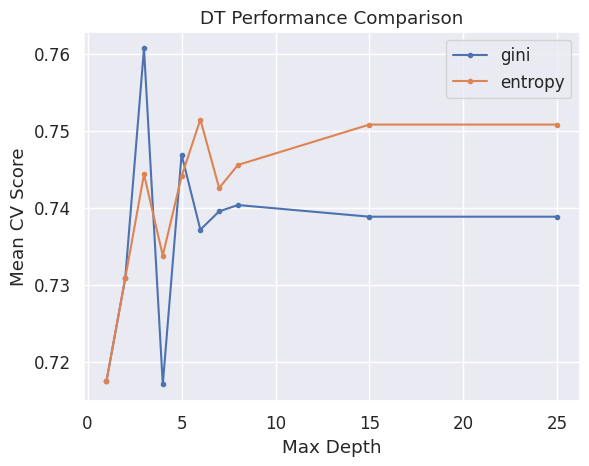

In [59]:
for i in ['gini', 'entropy']:
    temp = results_DT[results_DT['criterion'] == i]
    temp_average = temp.groupby('max_depth').agg({'test_score': 'mean'})
    plt.plot(temp_average, marker = '.', label = i)


plt.legend()
plt.xlabel('Max Depth')
plt.ylabel("Mean CV Score")
plt.title("DT Performance Comparison")
plt.show()

In [60]:
from sklearn.model_selection import cross_val_score,StratifiedKFold

In [61]:
scoring = {'accuracy' : make_scorer(accuracy_score),
           'precision' : make_scorer(precision_score),
           'recall' : make_scorer(recall_score),
           'f1_score' : make_scorer(f1_score)}
stratifiedkf=StratifiedKFold(n_splits=10,random_state=42,shuffle=True)
#cv = KFold(n_splits=10, random_state=1, shuffle=True)
DT_score = cross_validate(modelDT, X_train, y_train, cv=stratifiedkf, scoring=scoring)
print(DT_score)

print('accuracy',np.mean(DT_score['test_accuracy']))
print('precision',np.mean(DT_score['test_precision']))
print('recall',np.mean(DT_score['test_recall']))
print('f1 score',np.mean(DT_score['test_f1_score']))

{'fit_time': array([0.00336051, 0.00175166, 0.00206041, 0.00183272, 0.00170851,
       0.00182819, 0.00176454, 0.00211954, 0.00196576, 0.00175381]), 'score_time': array([0.01008558, 0.0084691 , 0.00865102, 0.00829363, 0.00815678,
       0.00818539, 0.00835967, 0.01096916, 0.00936866, 0.00951099]), 'test_accuracy': array([0.73913043, 0.73913043, 0.7826087 , 0.63636364, 0.81818182,
       0.77272727, 0.86363636, 0.72727273, 0.59090909, 0.77272727]), 'test_precision': array([0.7       , 1.        , 0.72727273, 0.6       , 0.75      ,
       0.85714286, 1.        , 0.75      , 0.54545455, 0.77777778]), 'test_recall': array([0.7, 0.4, 0.8, 0.6, 0.9, 0.6, 0.7, 0.6, 0.6, 0.7]), 'test_f1_score': array([0.7       , 0.57142857, 0.76190476, 0.6       , 0.81818182,
       0.70588235, 0.82352941, 0.66666667, 0.57142857, 0.73684211])}
accuracy 0.7442687747035572
precision 0.7707647907647908
recall 0.6599999999999999
f1 score 0.695586425957943


**RANDOM FOREST**





In [62]:
from sklearn.ensemble import RandomForestClassifier

modelRF = RandomForestClassifier(random_state=42,min_samples_split=2,min_samples_leaf=1,bootstrap=False,n_estimators=100,max_depth=None)

# fit the predictor and target
modelRF.fit(X_train, y_train)

# predict
y_pred = modelRF.predict(X_test)# check performance
print('ROCAUC score:',roc_auc_score(y_test, y_pred))
y_pred_train = modelRF.predict (X_train)
print("\n\n\t RANDOM CLASSIFIER")
metric_calc(y_test,y_pred)
print_metric()

ROCAUC score: 0.8516129032258064


	 RANDOM CLASSIFIER
 Specificity or true negative rate : 0.9032258064516129
Confusion Matrix - Train:  
 [[123   0]
 [  0 100]]

 Accuracy - Train:  1.0
Accuracy - Test:  0.8571428571428571
confusion matrix - Test  : [[28  3]
 [ 5 20]]
mean absolute error  model:  0.14285714285714285

Classification report for test:
               precision    recall  f1-score   support

           0       0.85      0.90      0.88        31
           1       0.87      0.80      0.83        25

    accuracy                           0.86        56
   macro avg       0.86      0.85      0.85        56
weighted avg       0.86      0.86      0.86        56



In [63]:
from sklearn.model_selection import RandomizedSearchCV
from pprint import pprint
# Number of trees in random forest
n_estimators = [int(x) for x in np.linspace(start = 1, stop = 100, num = 2)]
# Number of features to consider at every split
max_features = ['auto', 'sqrt']
# Maximum number of levels in tree
max_depth = [int(x) for x in np.linspace(4, 20, num = 1)]
max_depth.append(None)
# Minimum number of samples required to split a node
min_samples_split = [2, 5, 10]
# Minimum number of samples required at each leaf node
min_samples_leaf = [1, 2, 4]
# Method of selecting samples for training each tree
bootstrap = [True, False]
# Create the random grid
random_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf,
               'bootstrap': bootstrap}
pprint(random_grid)


{'bootstrap': [True, False],
 'max_depth': [4, None],
 'max_features': ['auto', 'sqrt'],
 'min_samples_leaf': [1, 2, 4],
 'min_samples_split': [2, 5, 10],
 'n_estimators': [1, 100]}


In [64]:
rf_random = RandomizedSearchCV(estimator = modelRF, param_distributions = random_grid, n_iter = 10, cv = 5, verbose=2, random_state=42, n_jobs = -1)
# Fit the random search model
rf_random.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5,
                   estimator=RandomForestClassifier(bootstrap=False,
                                                    random_state=42),
                   n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [4, None],
                                        'max_features': ['auto', 'sqrt'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [1, 100]},
                   random_state=42, verbose=2)

In [65]:
rf_random.best_params_

{'n_estimators': 100,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'max_features': 'sqrt',
 'max_depth': 4,
 'bootstrap': True}

In [66]:
rf_random.best_score_

np.float64(0.8338383838383837)

In [67]:
scoring = {'accuracy' : make_scorer(accuracy_score),
           'precision' : make_scorer(precision_score),
           'recall' : make_scorer(recall_score),
           'f1_score' : make_scorer(f1_score)}

stratifiedkf=StratifiedKFold(n_splits=10,random_state=42,shuffle=True)
rfc_score = cross_validate(modelRF, X_train, y_train, cv=stratifiedkf,scoring=scoring)
print(rfc_score)

print('accuracy',np.mean(rfc_score['test_accuracy']))
print('precision',np.mean(rfc_score['test_precision']))
print('recall',np.mean(rfc_score['test_recall']))
print('f1 score',np.mean(rfc_score['test_f1_score']))

{'fit_time': array([0.21137381, 0.22114515, 0.20471334, 0.20875025, 0.21059251,
       0.2064023 , 0.23691869, 0.2182858 , 0.16781187, 0.13308144]), 'score_time': array([0.02253866, 0.03189087, 0.02208591, 0.0253346 , 0.02183199,
       0.02868652, 0.02521563, 0.0262084 , 0.01747131, 0.01578951]), 'test_accuracy': array([0.73913043, 0.91304348, 0.86956522, 0.68181818, 0.81818182,
       0.81818182, 0.90909091, 0.95454545, 0.59090909, 0.86363636]), 'test_precision': array([0.66666667, 1.        , 0.88888889, 0.63636364, 0.75      ,
       1.        , 1.        , 1.        , 0.54545455, 0.81818182]), 'test_recall': array([0.8, 0.8, 0.8, 0.7, 0.9, 0.6, 0.8, 0.9, 0.6, 0.9]), 'test_f1_score': array([0.72727273, 0.88888889, 0.84210526, 0.66666667, 0.81818182,
       0.75      , 0.88888889, 0.94736842, 0.57142857, 0.85714286])}
accuracy 0.8158102766798419
precision 0.8305555555555555
recall 0.78
f1 score 0.7957944102680944


**LOGISTIC REGRESSION**

In [68]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

modelLR = LogisticRegression(solver='liblinear', fit_intercept=True)
modelLR.fit(X_train,y_train)

y_pred = modelLR.predict(X_test)
y_pred_train = modelLR.predict (X_train)

print("\n\n\t LOGISTIC REGRESSION")
metric_calc(y_test,y_pred)
print_metric()



	 LOGISTIC REGRESSION
 Specificity or true negative rate : 0.9032258064516129
Confusion Matrix - Train:  
 [[114   9]
 [ 19  81]]

 Accuracy - Train:  0.874439461883408
Accuracy - Test:  0.8571428571428571
confusion matrix - Test  : [[28  3]
 [ 5 20]]
mean absolute error  model:  0.14285714285714285

Classification report for test:
               precision    recall  f1-score   support

           0       0.85      0.90      0.88        31
           1       0.87      0.80      0.83        25

    accuracy                           0.86        56
   macro avg       0.86      0.85      0.85        56
weighted avg       0.86      0.86      0.86        56



In [69]:
scoring = {'accuracy' : make_scorer(accuracy_score),
           'precision' : make_scorer(precision_score),
           'recall' : make_scorer(recall_score),
           'f1_score' : make_scorer(f1_score)}
stratifiedkf=StratifiedKFold(n_splits=20,random_state=42,shuffle=True)
#cv = KFold(n_splits=10, random_state=42, shuffle=True)
LR_score = cross_validate(modelLR, X_train, y_train, cv=stratifiedkf, scoring=scoring)
print(LR_score)

print('accuracy',np.mean(LR_score['test_accuracy']))
print('precision',np.mean(LR_score['test_precision']))
print('recall',np.mean(LR_score['test_recall']))

print('F1 score',np.mean(LR_score['test_f1_score']))

{'fit_time': array([0.00385952, 0.00186539, 0.00188231, 0.00198674, 0.0018661 ,
       0.00185347, 0.00181079, 0.00182223, 0.00187135, 0.00209665,
       0.00180554, 0.00186229, 0.00187087, 0.00187802, 0.00195622,
       0.00177455, 0.00183606, 0.00231004, 0.00209904, 0.00199723]), 'score_time': array([0.00801516, 0.00729394, 0.00878048, 0.00770307, 0.0072875 ,
       0.00736809, 0.00751257, 0.0073514 , 0.00724244, 0.00727367,
       0.00720572, 0.00729871, 0.0073638 , 0.00720716, 0.00819969,
       0.00742507, 0.01037312, 0.0099318 , 0.00745273, 0.01154709]), 'test_accuracy': array([0.75      , 0.91666667, 1.        , 1.        , 0.90909091,
       0.81818182, 0.90909091, 0.63636364, 0.81818182, 0.81818182,
       0.63636364, 0.90909091, 0.90909091, 0.90909091, 0.90909091,
       0.90909091, 0.63636364, 0.54545455, 0.81818182, 0.81818182]), 'test_precision': array([0.66666667, 1.        , 1.        , 1.        , 0.83333333,
       1.        , 1.        , 0.6       , 0.8       , 0.8   

KNN

In [70]:
#k nearest neighbour  KNN model
from sklearn.neighbors import KNeighborsClassifier
modelKNN = KNeighborsClassifier(leaf_size=1,n_neighbors=26, p = 1)
# fit the predictor and target
modelKNN.fit(X_train, y_train)
# predict
y_pred = modelKNN.predict(X_test)# check performance
y_pred_train = modelKNN.predict (X_train)
print("\n\n\t K- nearest Neighbour CLASSIFIER")
metric_calc(y_test,y_pred)
print_metric()



	 K- nearest Neighbour CLASSIFIER
 Specificity or true negative rate : 0.967741935483871
Confusion Matrix - Train:  
 [[114   9]
 [ 22  78]]

 Accuracy - Train:  0.8609865470852018
Accuracy - Test:  0.9107142857142857
confusion matrix - Test  : [[30  1]
 [ 4 21]]
mean absolute error  model:  0.08928571428571429

Classification report for test:
               precision    recall  f1-score   support

           0       0.88      0.97      0.92        31
           1       0.95      0.84      0.89        25

    accuracy                           0.91        56
   macro avg       0.92      0.90      0.91        56
weighted avg       0.91      0.91      0.91        56



In [71]:
leaf_size = list(range(1,50))
n_neighbors = list(range(1,30))
p=[1,2]
#Convert to dictionary
hyperparameters = dict(leaf_size=leaf_size, n_neighbors=n_neighbors, p=p)
#Use GridSearch
clf = GridSearchCV(modelKNN, hyperparameters, cv=10)
#Fit the model
best_model = clf.fit(X_train, y_train)
#Print The value of best Hyperparameters
print('Best leaf_size:', best_model.best_estimator_.get_params()['leaf_size'])
print('Best p:', best_model.best_estimator_.get_params()['p'])
print('Best n_neighbors:', best_model.best_estimator_.get_params()['n_neighbors'])

Best leaf_size: 1
Best p: 1
Best n_neighbors: 26


In [72]:
k_range = list(range(1, 25))
k_scores = []
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn,  X_train, y_train, cv=10, scoring='accuracy')
    k_scores.append(scores.mean())
print(k_scores)

[np.float64(0.8114624505928854), np.float64(0.8110671936758894), np.float64(0.8160079051383399), np.float64(0.8156126482213439), np.float64(0.8156126482213439), np.float64(0.8290513833992096), np.float64(0.8472332015810276), np.float64(0.8288537549407116), np.float64(0.8108695652173914), np.float64(0.833399209486166), np.float64(0.842490118577075), np.float64(0.842490118577075), np.float64(0.8292490118577076), np.float64(0.8337944664031621), np.float64(0.842687747035573), np.float64(0.8337944664031621), np.float64(0.8381422924901185), np.float64(0.842490118577075), np.float64(0.8381422924901185), np.float64(0.8381422924901185), np.float64(0.8294466403162055), np.float64(0.8472332015810278), np.float64(0.8472332015810278), np.float64(0.842885375494071)]


Text(0, 0.5, 'Cross-Validated-Accuracy')

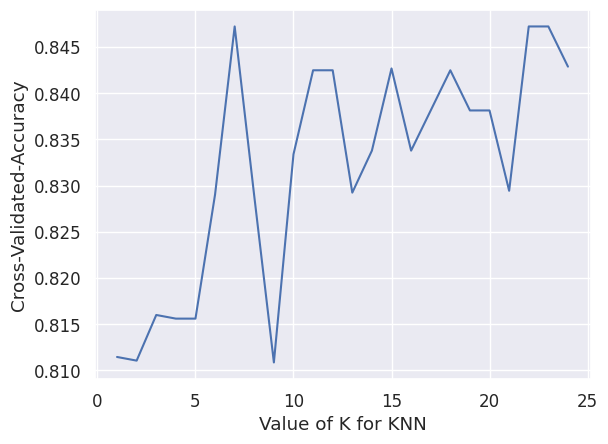

In [73]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.plot(k_range, k_scores)
plt.xlabel('Value of K for KNN')
plt.ylabel('Cross-Validated-Accuracy')

In [74]:
scoring = {'accuracy' : make_scorer(accuracy_score),
           'precision' : make_scorer(precision_score),
           'recall' : make_scorer(recall_score),
           'f1_score' : make_scorer(f1_score)}

stratifyKF=StratifiedKFold(n_splits=10,random_state=42,shuffle=True)
KNN_score= cross_validate(modelKNN, X_train, y_train, cv=stratifyKF,scoring=scoring)
print(KNN_score)

print('accuracy',np.mean(KNN_score['test_accuracy']))
print('precision',np.mean(KNN_score['test_precision']))
print('recall',np.mean(KNN_score['test_recall']))
print('f1 score',np.mean(KNN_score['test_f1_score']))

{'fit_time': array([0.00178719, 0.00113678, 0.00144434, 0.00159645, 0.00117803,
       0.00105858, 0.00105906, 0.00104785, 0.00110793, 0.00111127]), 'score_time': array([0.01207709, 0.01086426, 0.0134201 , 0.01481676, 0.00917625,
       0.00890112, 0.00883174, 0.00936913, 0.00916386, 0.01179647]), 'test_accuracy': array([0.7826087 , 1.        , 0.91304348, 0.81818182, 0.86363636,
       0.81818182, 0.90909091, 0.90909091, 0.63636364, 0.90909091]), 'test_precision': array([0.77777778, 1.        , 1.        , 0.875     , 0.81818182,
       1.        , 1.        , 1.        , 0.6       , 0.9       ]), 'test_recall': array([0.7, 1. , 0.8, 0.7, 0.9, 0.6, 0.8, 0.8, 0.6, 0.9]), 'test_f1_score': array([0.73684211, 1.        , 0.88888889, 0.77777778, 0.85714286,
       0.75      , 0.88888889, 0.88888889, 0.6       , 0.9       ])}
accuracy 0.8559288537549407
precision 0.8970959595959597
recall 0.78
f1 score 0.8288429406850459


SVM

In [75]:
from sklearn import svm
modelSVM_rbf = svm.SVC(kernel='rbf',gamma=0.01 , C=10,random_state=42, probability =True)  #Sigmoid kernel
#Train the model using the training sets
modelSVM_rbf.fit(X_train, y_train.ravel())

#Predict the response for train dataset
y_pred_train = modelSVM_rbf.predict(X_train)
#Predict the response for test dataset
y_pred = modelSVM_rbf.predict(X_test)
metric_calc(y_test,y_pred)
print_metric()



 Specificity or true negative rate : 0.967741935483871
Confusion Matrix - Train:  
 [[117   6]
 [ 17  83]]

 Accuracy - Train:  0.8968609865470852
Accuracy - Test:  0.875
confusion matrix - Test  : [[30  1]
 [ 6 19]]
mean absolute error  model:  0.125

Classification report for test:
               precision    recall  f1-score   support

           0       0.83      0.97      0.90        31
           1       0.95      0.76      0.84        25

    accuracy                           0.88        56
   macro avg       0.89      0.86      0.87        56
weighted avg       0.89      0.88      0.87        56



In [76]:
from sklearn.utils import shuffle
from sklearn import svm
# cross validation of SVM using Grid search CV

from sklearn.model_selection import GridSearchCV

# defining parameter range
param_grid = {'C': [0.1, 1, 10, 100],
              'gamma': [1, 0.1, 0.01, 0.001],
              'kernel': ['rbf']
              }

grid = GridSearchCV(svm.SVC(random_state=42), param_grid, refit = True, verbose = 3)

# fitting the model for grid search
grid.fit(X_train, y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.556 total time=   0.0s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.556 total time=   0.0s
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.556 total time=   0.0s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.545 total time=   0.0s
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.545 total time=   0.0s
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.689 total time=   0.0s
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.600 total time=   0.0s
[CV 3/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.644 total time=   0.0s
[CV 4/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.705 total time=   0.0s
[CV 5/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.682 total time=   0.0s
[CV 1/5] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.889 total time=   0.0s
[CV 2/5] END .....C=0.1, gamma=0.01, kernel=rbf;

GridSearchCV(estimator=SVC(random_state=42),
             param_grid={'C': [0.1, 1, 10, 100], 'gamma': [1, 0.1, 0.01, 0.001],
                         'kernel': ['rbf']},
             verbose=3)

In [77]:
# print best parameter after tuning
print(grid.best_params_)

# print how our model looks after hyper-parameter tuning
print(grid.best_estimator_)

{'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
SVC(C=10, gamma=0.01, random_state=42)


In [78]:
scoring = {'accuracy' : make_scorer(accuracy_score),
           'precision' : make_scorer(precision_score),
           'recall' : make_scorer(recall_score),
           'f1_score' : make_scorer(f1_score)}

cv=KFold(n_splits=10,random_state=42,shuffle=True)
svm_score= cross_validate(modelSVM_rbf, X_train, y_train, cv=cv,scoring=scoring)
print(svm_score)

print('accuracy',np.mean(svm_score['test_accuracy']))
print('precision',np.mean(svm_score['test_precision']))
print('recall',np.mean(svm_score['test_recall']))
print('f1 score',np.mean(svm_score['test_f1_score']))

{'fit_time': array([0.01126623, 0.00814486, 0.01075292, 0.00793028, 0.00854206,
       0.00807834, 0.00819325, 0.00814176, 0.00828147, 0.00847125]), 'score_time': array([0.0091877 , 0.01078248, 0.01130271, 0.00859857, 0.00869918,
       0.0093329 , 0.00859404, 0.00915933, 0.00851297, 0.00944495]), 'test_accuracy': array([0.95652174, 0.86956522, 0.95652174, 0.77272727, 0.90909091,
       0.77272727, 0.77272727, 0.77272727, 0.72727273, 0.86363636]), 'test_precision': array([0.90909091, 0.75      , 1.        , 0.91666667, 0.75      ,
       0.77777778, 0.84615385, 0.71428571, 0.77777778, 1.        ]), 'test_recall': array([1.        , 0.85714286, 0.90909091, 0.73333333, 1.        ,
       0.7       , 0.78571429, 0.625     , 0.63636364, 0.625     ]), 'test_f1_score': array([0.95238095, 0.8       , 0.95238095, 0.81481481, 0.85714286,
       0.73684211, 0.81481481, 0.66666667, 0.7       , 0.76923077])}
accuracy 0.8373517786561265
precision 0.844175269175269
recall 0.7871645021645022
f1 score

Ensembling

In [79]:
from sklearn.ensemble import VotingClassifier

#majority voting before oversampling

model_major = VotingClassifier(estimators=[('lr', modelLR), ('dt', modelDT),('knn', modelKNN),('RF',modelRF),('xgb', modelXGB),('svm', modelSVM_rbf)], voting='soft')
model_major.fit(X_train, y_train)
model_major.score(X_test,y_test)

0.875

In [80]:
scoring = {'accuracy' : make_scorer(accuracy_score),
           'precision' : make_scorer(precision_score),
           'recall' : make_scorer(recall_score),
           'f1_score' : make_scorer(f1_score)}

cv=KFold(n_splits=20,random_state=42,shuffle=True)
vote_score= cross_validate(model_major, X_train, y_train, cv=cv,scoring=scoring)
print(vote_score)

print('accuracy',np.mean(vote_score['test_accuracy']))
print('precision',np.mean(vote_score['test_precision']))
print('recall',np.mean(vote_score['test_recall']))
print('f1 score',np.mean(vote_score['test_f1_score']))

{'fit_time': array([0.23768091, 0.24343061, 0.23800063, 0.26873922, 0.23928785,
       0.24654245, 0.23447871, 0.27353096, 0.24171877, 0.24341011,
       0.23872542, 0.25289297, 0.24221897, 0.24282193, 0.24119687,
       0.25008059, 0.24173045, 0.2355814 , 0.25197315, 0.27735019]), 'score_time': array([0.02098227, 0.02368331, 0.02121019, 0.023911  , 0.0209198 ,
       0.02125478, 0.02142525, 0.02098894, 0.02361631, 0.02121592,
       0.02085948, 0.02108717, 0.02207303, 0.02109385, 0.02103114,
       0.02102232, 0.02166772, 0.02208614, 0.02117515, 0.02149081]), 'test_accuracy': array([0.75      , 0.91666667, 0.75      , 1.        , 0.90909091,
       0.90909091, 0.90909091, 0.54545455, 0.81818182, 1.        ,
       0.90909091, 0.72727273, 0.81818182, 0.81818182, 0.81818182,
       0.90909091, 1.        , 0.54545455, 0.72727273, 0.90909091]), 'test_precision': array([0.57142857, 0.85714286, 0.66666667, 1.        , 0.75      ,
       1.        , 1.        , 0.6       , 0.5       , 1.    

In [81]:
from sklearn.ensemble import AdaBoostClassifier
modelada = AdaBoostClassifier(n_estimators=10,learning_rate=1)
modelada.fit(X_train, y_train)
modelada.score(X_test,y_test)

0.7321428571428571

In [82]:
# creating a dic for the grid
grid = dict()

# estimator till 100
grid['n_estimators'] = [5, 10, 25, 50, 100]

# defining learning rate
grid['learning_rate'] = [0.0001, 0.01, 0.1, 1.0]


# defining the CV
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3)

# initializing the grid search
grid_search = GridSearchCV(estimator=modelada, param_grid=grid, n_jobs=-1, cv=cv, scoring='accuracy')


# training the model on grid search for hyperparameter tuning of Adaboost
grid_result = grid_search.fit(X_train, y_train)

# finding the best results /hyperparameter tuning of Adaboost
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))

Best: 0.842095 using {'learning_rate': 0.1, 'n_estimators': 100}


In [83]:
scoring = {'accuracy' : make_scorer(accuracy_score),
           'precision' : make_scorer(precision_score),
           'recall' : make_scorer(recall_score),
           'f1_score' : make_scorer(f1_score)}

cv=KFold(n_splits=10,random_state=42,shuffle=True)
ada_score= cross_validate(modelada, X_train, y_train, cv=cv,scoring=scoring)
print(vote_score)

print('accuracy',np.mean(ada_score['test_accuracy']))
print('precision',np.mean(ada_score['test_precision']))
print('recall',np.mean(ada_score['test_recall']))
print('f1 score',np.mean(ada_score['test_f1_score']))

{'fit_time': array([0.23768091, 0.24343061, 0.23800063, 0.26873922, 0.23928785,
       0.24654245, 0.23447871, 0.27353096, 0.24171877, 0.24341011,
       0.23872542, 0.25289297, 0.24221897, 0.24282193, 0.24119687,
       0.25008059, 0.24173045, 0.2355814 , 0.25197315, 0.27735019]), 'score_time': array([0.02098227, 0.02368331, 0.02121019, 0.023911  , 0.0209198 ,
       0.02125478, 0.02142525, 0.02098894, 0.02361631, 0.02121592,
       0.02085948, 0.02108717, 0.02207303, 0.02109385, 0.02103114,
       0.02102232, 0.02166772, 0.02208614, 0.02117515, 0.02149081]), 'test_accuracy': array([0.75      , 0.91666667, 0.75      , 1.        , 0.90909091,
       0.90909091, 0.90909091, 0.54545455, 0.81818182, 1.        ,
       0.90909091, 0.72727273, 0.81818182, 0.81818182, 0.81818182,
       0.90909091, 1.        , 0.54545455, 0.72727273, 0.90909091]), 'test_precision': array([0.57142857, 0.85714286, 0.66666667, 1.        , 0.75      ,
       1.        , 1.        , 0.6       , 0.5       , 1.    

In [84]:
from sklearn.ensemble import BaggingClassifier
from sklearn import tree
modelBag = BaggingClassifier(tree.DecisionTreeClassifier(random_state=42))
modelBag.fit(X_train, y_train)
modelBag.score(X_test,y_test)

0.875

In [85]:
scoring = {'accuracy' : make_scorer(accuracy_score),
           'precision' : make_scorer(precision_score),
           'recall' : make_scorer(recall_score),
           'f1_score' : make_scorer(f1_score)}

cv=KFold(n_splits=20,random_state=42,shuffle=True)
bag_score= cross_validate(modelBag, X_train, y_train, cv=cv,scoring=scoring)
print(vote_score)

print('accuracy',np.mean(bag_score['test_accuracy']))
print('precision',np.mean(bag_score['test_precision']))
print('recall',np.mean(bag_score['test_recall']))
print('f1 score',np.mean(bag_score['test_f1_score']))

{'fit_time': array([0.23768091, 0.24343061, 0.23800063, 0.26873922, 0.23928785,
       0.24654245, 0.23447871, 0.27353096, 0.24171877, 0.24341011,
       0.23872542, 0.25289297, 0.24221897, 0.24282193, 0.24119687,
       0.25008059, 0.24173045, 0.2355814 , 0.25197315, 0.27735019]), 'score_time': array([0.02098227, 0.02368331, 0.02121019, 0.023911  , 0.0209198 ,
       0.02125478, 0.02142525, 0.02098894, 0.02361631, 0.02121592,
       0.02085948, 0.02108717, 0.02207303, 0.02109385, 0.02103114,
       0.02102232, 0.02166772, 0.02208614, 0.02117515, 0.02149081]), 'test_accuracy': array([0.75      , 0.91666667, 0.75      , 1.        , 0.90909091,
       0.90909091, 0.90909091, 0.54545455, 0.81818182, 1.        ,
       0.90909091, 0.72727273, 0.81818182, 0.81818182, 0.81818182,
       0.90909091, 1.        , 0.54545455, 0.72727273, 0.90909091]), 'test_precision': array([0.57142857, 0.85714286, 0.66666667, 1.        , 0.75      ,
       1.        , 1.        , 0.6       , 0.5       , 1.    

In [94]:
from sklearn.datasets import make_classification
from sklearn.ensemble import StackingClassifier

# get a stacking ensemble of models
def get_stacking():
  # define the base models
  level0 = list()
  level0.append(('lr', modelLR))
  level0.append(('xgb', modelXGB))
  level0.append(('rf', modelRF))
  level0.append(('knn',modelKNN))
  level0.append(('dt', modelDT))
  level0.append(('bagging', modelBag))
  level0.append(('svm', modelSVM_rbf))
  level0.append(('ada', modelada))

  # define meta learner model
  level1 = KNeighborsClassifier()
  # define the stacking ensemble
  model = StackingClassifier(estimators=level0, final_estimator=level1, cv=10)
  model.fit(X_train,y_train)
  y_pred_stack= model.predict(X_test)

  return model


def get_models():
  modelsdict = {'lr':modelLR,'xgb': modelXGB, 'rf': modelRF,'knn': modelKNN,'dt' : modelDT,'bag': modelBag,'svm' : modelSVM_rbf,'ada' : modelada,  'stacking' : get_stacking()}
  return modelsdict

In [92]:
def evaluate_model(modelsdict):

  cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=42)

  scores = cross_val_score(modelsdict,X_train, y_train, scoring='accuracy', cv=cv, n_jobs=-1, error_score='raise')

  return scores


>lr 0.838 (0.078)
>xgb 0.830 (0.089)
>rf 0.820 (0.083)
>knn 0.852 (0.077)
>dt 0.764 (0.070)
>bag 0.783 (0.089)
>svm 0.856 (0.077)
>ada 0.830 (0.089)
>stacking 0.822 (0.088)


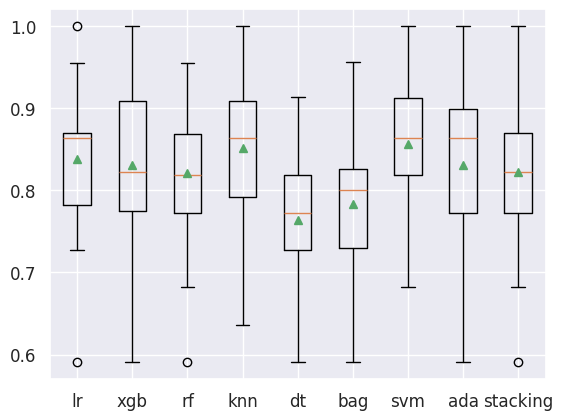

In [95]:
from numpy import mean
from numpy import std
from matplotlib import pyplot
# get the models to evaluate
modelsdict = get_models()
# evaluate the models and store results
results, names = list(), list()
for name, modelsdict in modelsdict.items():
	scores = evaluate_model(modelsdict)
	results.append(scores)
	names.append(name)
	print('>%s %.3f (%.3f)' % (name, mean(scores), std(scores)))
# plot model performance for comparison
pyplot.boxplot(results, labels=names, showmeans=True)
pyplot.show()

In [96]:
scoring = {'accuracy' : make_scorer(accuracy_score),
           'precision' : make_scorer(precision_score),
           'recall' : make_scorer(recall_score),
           'f1_score' : make_scorer(f1_score)}

cv=KFold(n_splits=25,random_state=42,shuffle=True)
stackscore= cross_validate(modelsdict, X_train, y_train, cv=cv,scoring=scoring)
print(stackscore)

print('accuracy',np.mean(stackscore['test_accuracy']))
print('precision',np.mean(stackscore['test_precision']))
print('recall',np.mean(stackscore['test_recall']))
print('f1 score',np.mean(stackscore['test_f1_score']))

{'fit_time': array([3.25029564, 5.27215052, 3.21167111, 3.25183463, 4.06334519,
       3.79763508, 3.28302836, 3.2421298 , 5.45088315, 3.24058461,
       3.2430346 , 4.26944685, 3.40360117, 3.24313545, 3.22355294,
       5.40016055, 3.2487607 , 3.26936722, 4.28162408, 3.30919886,
       3.22777414, 3.27033281, 5.35517597, 3.2684896 , 3.28514409]), 'score_time': array([0.02783394, 0.02761531, 0.02916074, 0.03808451, 0.06342864,
       0.031497  , 0.02787471, 0.02789307, 0.0381248 , 0.02935958,
       0.0302    , 0.05716228, 0.0272572 , 0.02770257, 0.02864432,
       0.0296514 , 0.02799797, 0.02787566, 0.07246852, 0.02794003,
       0.02737927, 0.02754068, 0.03160667, 0.02968383, 0.02756786]), 'test_accuracy': array([0.77777778, 1.        , 0.77777778, 0.77777778, 0.77777778,
       0.88888889, 0.88888889, 0.88888889, 0.77777778, 0.44444444,
       0.88888889, 0.88888889, 0.88888889, 1.        , 0.66666667,
       0.66666667, 0.66666667, 1.        , 0.77777778, 1.        ,
       0.88888

In [97]:
from numpy import mean, std
import pandas as pd
from matplotlib import pyplot

models = get_models()

results = []
names = []
summary = []

for name, model in models.items():
    scores = evaluate_model(model)

    results.append(scores)
    names.append(name)

    summary.append({
        "Model": name,
        "CV Mean": mean(scores),
        "CV Std": std(scores)
    })

    print(f"{name}: Mean={mean(scores):.3f}, Std={std(scores):.3f}")

# Convert to DataFrame
cv_results_df = pd.DataFrame(summary).sort_values(by="CV Mean", ascending=False)
cv_results_df

lr: Mean=0.838, Std=0.078
xgb: Mean=0.830, Std=0.089
rf: Mean=0.820, Std=0.083
knn: Mean=0.852, Std=0.077
dt: Mean=0.764, Std=0.070
bag: Mean=0.776, Std=0.091
svm: Mean=0.856, Std=0.077
ada: Mean=0.830, Std=0.089
stacking: Mean=0.817, Std=0.090


,Model,CV Mean,CV Std
6,svm,0.856126,0.076864
3,knn,0.851713,0.076607
0,lr,0.838208,0.078246
1,xgb,0.830435,0.088652
7,ada,0.830435,0.089360
2,rf,0.820487,0.083084
8,stacking,0.817391,0.090162
5,bag,0.775626,0.090940
4,dt,0.763702,0.069532


## 🔍 Cross-Validation Insights

- Stacking ensemble achieved the highest mean accuracy, indicating strong generalization.
- Tree-based models (Random Forest, Gradient Boosting) showed lower variance compared to linear models.
- Low standard deviation across folds suggests model stability.
- Cross-validation confirms that the model is not overfitting.

##CONNECT THIS WITH SHAP
- SHAP analysis confirms that key features such as age, cholesterol, and maximum heart rate significantly influence predictions.

In [99]:
!pip install shap


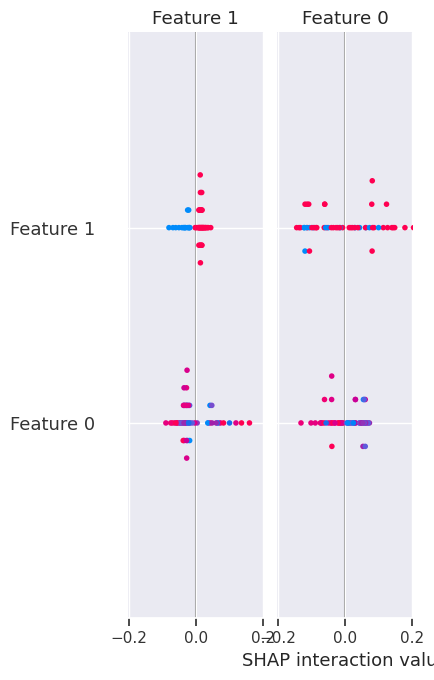

In [106]:
import shap
import numpy as np
import matplotlib.pyplot as plt
import os

# Choose a tree-based model (best for SHAP)
model = models["rf"]

# Use a subset for speed (important for Colab)
X_sample = X_train[:100]

# Create explainer
explainer = shap.Explainer(model, X_sample)

# Calculate SHAP values
shap_values = explainer(X_test[:100], check_additivity=False)

# Plot summary
shap.summary_plot(shap_values, X_test[:100], show=False)

# Create the directory if it doesn't exist
output_dir = '/outputs/'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Save plot
plt.savefig(os.path.join(output_dir, 'shap_summary.png'))
plt.show()

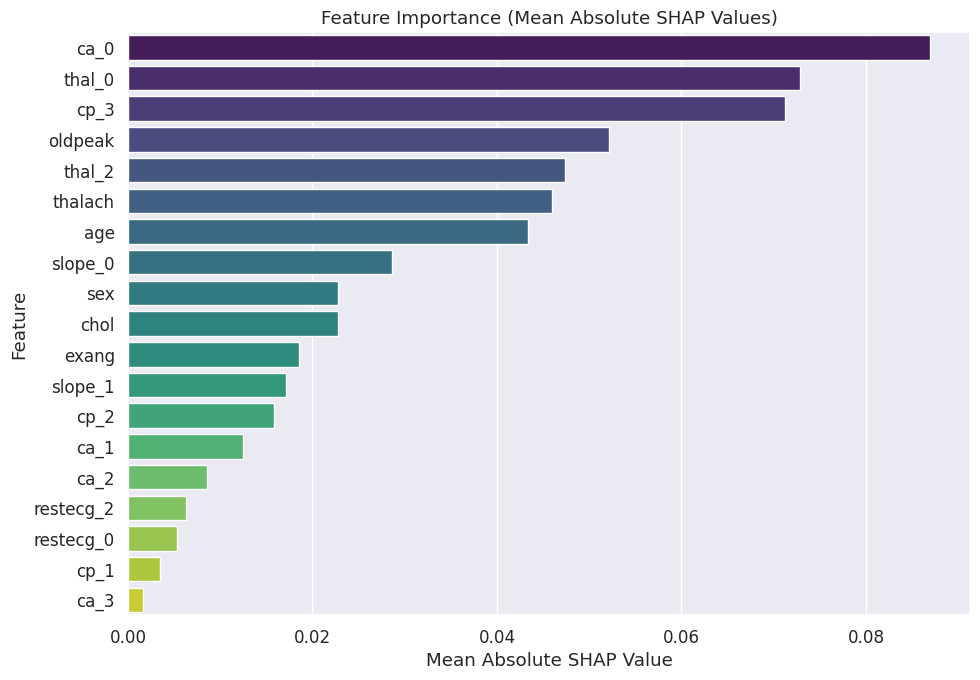

In [109]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate mean absolute SHAP values for each feature, focusing on the positive class (index 1)
mean_abs_shap_values = np.abs(shap_values.values).mean(axis=0)[:, 1]

# Get feature names from the original DataFrame X
feature_names = X.columns

# Create a pandas Series for easier sorting and plotting
shap_importance = pd.Series(mean_abs_shap_values, index=feature_names).sort_values(ascending=False)

# Plot the feature importance
plt.figure(figsize=(10, 7))
sns.barplot(x=shap_importance.values, y=shap_importance.index, palette='viridis')
plt.title('Feature Importance (Mean Absolute SHAP Values)')
plt.xlabel('Mean Absolute SHAP Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [111]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 8.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=30af68d4d2fd07b1959b890e14e7861a29555b236bb3276cbccb451de2c897b5
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [112]:
from lime.lime_tabular import LimeTabularExplainer

# Create explainer
lime_explainer = LimeTabularExplainer(
    training_data=X_train,
    feature_names=df.columns[:-1],
    class_names=['No Disease', 'Disease'],
    mode='classification'
)

# Explain ONE prediction
i = 0  # you can change index

exp = lime_explainer.explain_instance(
    X_test[i],
    models["rf"].predict_proba
)

# Show result
exp.show_in_notebook(show_table=True)

In [113]:
exp.save_to_file('/outputs/lime_explanation.html')



### SHAP (Global Interpretation)
SHAP values help identify the most important features influencing model predictions across the dataset.

### LIME (Local Interpretation)
LIME explains individual predictions by approximating the model locally.